# **<span style="color:#48B3AF; font-family: 'Courier New"> LOAD </span>**

## **<span style="color:#476EAE; font-family: 'Courier New"> Resources </span>**

In [64]:
# Infrastructure
import os
import pandas as pd
import numpy as np
# Locations
os.makedirs("reporting", exist_ok=True)

In [92]:
# Import files for loading
dc_dci_coverage = pd.read_csv("loading/dc_dci_coverage_labels.csv", dtype=str)
df_full = pd.read_csv("loading/df_full_labels.csv", dtype=str)

In [84]:
dc_dci_coverage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1467 entries, 0 to 1466
Data columns (total 14 columns):
 #   Column                                     Non-Null Count  Dtype 
---  ------                                     --------------  ----- 
 0   Cod DCI                                    1265 non-null   object
 1   Denumirea Comuna Internationala (DCI)      1467 non-null   object
 2   Cod DCI_sec                                591 non-null    object
 3   Denumirea comună internațională (DCI)      41 non-null     object
 4   Cod DC                                     1265 non-null   object
 5   Cod DC_sec                                 590 non-null    object
 6   Denumirea comercială (DC)                  1467 non-null   object
 7   Cod ATC                                    1467 non-null   object
 8   coverage_type                              1467 non-null   object
 9   Grupa maladiilor pentru compensare         1467 non-null   object
 10  Cod CIM 
de diagnostic/limitare indi

In [85]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52735 entries, 0 to 52734
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Código nacional                 50737 non-null  object
 1   Cód. ATC_pres                   52735 non-null  object
 2   Situación de financiación       19451 non-null  object
 3   Principios Activos_pres         52735 non-null  object
 4   Principio activo o asociación*  31245 non-null  object
 5   Principios Activos_form         52735 non-null  object
 6   Nº P. Activos                   52735 non-null  object
 7   Presentación                    52735 non-null  object
 8   Nombre del medicamento          50737 non-null  object
 9   Medicamento                     52735 non-null  object
 10  Laboratorio_pres                52735 non-null  object
 11  manufacturer_label              52735 non-null  object
 12  Estado_pres                     52735 non-null

#### Library of unique names of the active compounds

<hr style="border: none; border-top: 6px solid #FFF111;">

In [170]:
# Unify column names with similar information
drug_cover_md = dc_dci_coverage[["Cod DCI", "Denumirea Comuna Internationala (DCI)", "Cod DCI_sec", "Denumirea comună internațională (DCI)", "Cod DC", "Cod DC_sec", "Denumirea comercială (DC)", "Cod ATC", "coverage_type", "Grupa maladiilor pentru compensare", "Firma producătoare", "manufacturer_label", "Ţara"]]
drug_cover_md["is_covered"] = True
unify_map_md = {
    "Cod DCI": "dci_code", 
    "Denumirea Comuna Internationala (DCI)": "dci_name", 
    "Cod DCI_sec": "dci_code_sec",
    "Denumirea comună internațională (DCI)": "dci_name_sec", 
    "Cod DC": "dc_code_prim", 
    "Cod DC_sec": "dc_code_sec", 
    "Denumirea comercială (DC)": "dc_name", 
    "Cod ATC": "atc_code", 
    "coverage_type": "coverage_level",
    "is_covered": "is_covered",
    "Grupa maladiilor pentru compensare": "disease_group", 
    "Firma producătoare": "manufacturer_name", 
    "manufacturer_label": "manufacturer_label", 
    "Ţara": "country"
}
drug_cover_md = drug_cover_md.copy()
drug_cover_md = drug_cover_md.rename(columns=unify_map_md)
drug_cover_md.head(2)

,dci_code,dci_name,dci_code_sec,dci_name_sec,dc_code_prim,dc_code_sec,dc_name,atc_code,coverage_level,disease_group,manufacturer_name,manufacturer_label,country,is_covered
0,37,PANCREATINUM,NaN,NaN,373002,NaN,Kreon® 10000,A09AA02,Full,Pentru tratamentul mucoviscidozei,Abbott Laboratories GmbH,Abbott Laboratories,Germania,True
1,37,PANCREATINUM,NaN,NaN,375004,NaN,Kreon® 25000,A09AA02,Full,Pentru tratamentul mucoviscidozei,Abbott Laboratories GmbH,Abbott Laboratories,Germania,True


In [95]:
drug_cover_md.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1467 entries, 0 to 1466
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   dci_code            1265 non-null   object
 1   dci_name            1467 non-null   object
 2   dci_code_sec        591 non-null    object
 3   dci_name_sec        41 non-null     object
 4   dc_code_prim        1265 non-null   object
 5   dc_code_sec         590 non-null    object
 6   dc_name             1467 non-null   object
 7   atc_code            1467 non-null   object
 8   coverage_level      1467 non-null   object
 9   disease_group       1467 non-null   object
 10  manufacturer_name   1467 non-null   object
 11  manufacturer_label  1467 non-null   object
 12  country             1467 non-null   object
 13  is_covered          1467 non-null   bool  
dtypes: bool(1), object(13)
memory usage: 150.6+ KB


In [171]:
drug_cover_es = df_full[["Código nacional", "Cód. ATC_pres", "Situación de financiación", "Principios Activos_pres", "Nº P. Activos", "Presentación", "Laboratorio_pres", "manufacturer_label", "country"]]
unify_map_es = {
    "Código nacional": "national_code", 
    "Principios Activos_pres": "dci_name",
    "Cód. ATC_pres": "atc_code", 
    "Nº P. Activos": "nr_act_compounds",
    "Presentación": "dc_name",
    "Situación de financiación": "is_covered",  
    "Laboratorio_pres": "manufacturer_name", 
    "manufacturer_label": "manufacturer_label", 
    "country": "country"
}
drug_cover_es = drug_cover_es.copy()
drug_cover_es = drug_cover_es.rename(columns=unify_map_es)
drug_cover_es.head(2)

,national_code,atc_code,is_covered,dci_name,nr_act_compounds,dc_name,manufacturer_name,manufacturer_label,country
0,600001,C02CA04,True,DOXAZOSINA MESILATO,1,DOXAZOSINA NEO TEVA-RATIOPHARM 4 mg COMPRIMIDO...,Teva Pharma S.L.U.,Teva,Spain
1,600002,R05CB01,True,ACETILCISTEINA,1,ACETILCISTEINA PENSA 600 mg POLVO PARA SOLUCIO...,Towa Pharmaceutical S.A.,Towa Pharmaceutical,Spain


In [96]:
drug_cover_es.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52735 entries, 0 to 52734
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   national_code       50737 non-null  object
 1   atc_code            52735 non-null  object
 2   is_covered          19451 non-null  object
 3   dci_name            52735 non-null  object
 4   nr_act_compounds    52735 non-null  object
 5   dc_name             52735 non-null  object
 6   manufacturer_name   52735 non-null  object
 7   manufacturer_label  52735 non-null  object
 8   country             52703 non-null  object
dtypes: object(9)
memory usage: 3.6+ MB


### **<span style="color:#476EAE; font-family: 'Courier New"> Fuzzy matching </span>**

In [ ]:
#Fuzzy matching
import pandas as pd
import re
from rapidfuzz import fuzz
from unidecode import unidecode
import warnings

# Column unification maps
unify_map_md = {
    "dci_code": "dci_code", 
    "dci_name": "dci_name", 
    "dci_code_sec": "dci_code_sec",
    "dci_name_sec": "dci_name_sec", 
    "dc_code_prim": "dc_code_prim", 
    "dc_code_sec": "dc_code_sec", 
    "dc_name": "dc_name", 
    "atc_code": "atc_code", 
    "coverage_level": "coverage_level",
    "disease_group": "disease_group", 
    "manufacturer_name": "manufacturer_name", 
    "manufacturer_label": "manufacturer_label", 
    "country": "country"
}

unify_map_es = {
    "national_code": "national_code",
    "atc_code": "atc_code",
    "is_covered": "is_covered",
    "dci_name": "dci_name",
    "nr_act_compounds": "nr_act_compounds",
    "dc_name": "dc_name",
    "manufacturer_name": "manufacturer_name",
    "manufacturer_label": "manufacturer_label",
    "country": "country"
}
# -----------------------------
# 1. NORMALIZATION
# -----------------------------
LATIN_TOKEN_MAP = {
    "acidum": "acido",
}

EXACT_NAME_MAP = {
    "acetylcysteinum": "acetilcisteina",
    "amiodaronum": "amiodarona",
    "acidum valproicum": "acido valproico",
    "acidum valproicum": "valproico acido",
}

def normalize_name(name: str, sort_tokens: bool = True) -> str:
    if pd.isna(name) or name is None:
        return ""

    name = str(name).lower().strip()
    name = unidecode(name)

    # remove punctuation first
    name = re.sub(r"[^\w\s/+,-]", " ", name)
    name = re.sub(r"\s+", " ", name).strip()

    # exact phrase overrides first
    if name in EXACT_NAME_MAP:
        normalized = EXACT_NAME_MAP[name]
    else:
        tokens = name.split()
        out = []

        for tok in tokens:
            if tok in LATIN_TOKEN_MAP:
                out.append(LATIN_TOKEN_MAP[tok])
                continue

            # common Latin -> ES pharmaceutical ending rules
            tok = re.sub(r"cysteinum$", "cisteina", tok)   # acetylcysteinum -> acetilcisteina after next rule
            tok = re.sub(r"acetyl", "acetil", tok)         # acetyl... -> acetil...
            tok = re.sub(r"onum$", "ona", tok)             # amiodaronum -> amiodarona
            tok = re.sub(r"inum$", "ina", tok)             # e.g. ...inum -> ...ina
            tok = re.sub(r"ium$", "io", tok)               # cautious generic rule
            tok = re.sub(r"icum$", "ico", tok)             # valproicum -> valproico
            tok = re.sub(r"um$", "o", tok)                 # fallback
            out.append(tok)

        normalized = " ".join(out)

    normalized = re.sub(r"\s+", " ", normalized).strip()

    if sort_tokens and normalized:
        normalized = " ".join(sorted(normalized.split()))

    return normalized


# -----------------------------
# 2. SPLIT COMPONENTS
# -----------------------------
def split_components(name: str):
    if not name:
        return []
    
    separators = r'\+|/| y |,| plus | PLUS '
    parts = re.split(separators, name)
    
    return [p.strip() for p in parts if p.strip()]

# -----------------------------
# 3. ATC MATCH CHECK
# -----------------------------
def check_atc_match(atc1, atc2):
    if pd.isna(atc1) or pd.isna(atc2):
        return False, False
    
    atc1 = str(atc1)
    atc2 = str(atc2)
    
    exact = atc1 == atc2
    prefix = atc1[:5] == atc2[:5]
    
    return exact, prefix

# -----------------------------
# 4. UNIFY COLUMNS
# -----------------------------
def unify_columns(df_md, df_es):
    # Make explicit copies to avoid SettingWithCopyWarning
    df_md = df_md.copy()
    df_es = df_es.copy()
    
    # Rename MD columns (already mostly unified)
    df_md.rename(columns=unify_map_md, inplace=True)
    
    # Rename ES columns
    df_es.rename(columns=unify_map_es, inplace=True)
    
    # Get common columns
    common_cols = list(df_md.columns.intersection(df_es.columns))
    print(f"Common columns: {common_cols}")
    
    return df_md[common_cols], df_es[common_cols], common_cols

# -----------------------------
# 5. PREPROCESS SPANISH DF (drug_cover_es)
# -----------------------------
def preprocess_es_df(df_es):
    df = df_es.copy()
    
    df["normalized_dci"] = df["dci_name"].apply(normalize_name)
    df["components"] = df["normalized_dci"].apply(split_components)
    
    return df

# -----------------------------
# 6. SINGLE COMPONENT SEARCH
# -----------------------------
def search_single_component(dci_name, df_es_prep, atc_code=None, threshold=90):
    norm_dci = normalize_name(dci_name)
    
    if not norm_dci:
        return None, "no_match"
    
    candidates = []
    
    # ALWAYS compute scores for ALL candidates, even below threshold
    for _, row in df_es_prep.iterrows():
        best_score = 0
        
        for comp in row["components"]:
            score = fuzz.token_sort_ratio(norm_dci, comp)
            best_score = max(best_score, score)
        
        # NEW: Always collect if ATC matches OR score is reasonable
        atc_exact, atc_prefix = check_atc_match(atc_code, row["atc_code"])
        
        # Include ALL ATC-exact matches regardless of name score
        # Include high prefix matches OR any score >= threshold
        if atc_exact or (atc_prefix and best_score >= 70) or best_score >= threshold:
            candidates.append({
                "row": row,
                "score": best_score,
                "atc_exact": atc_exact,
                "atc_prefix": atc_prefix
            })
    
    if not candidates:
        return None, "no_candidates"
    
    # NEW PRIORITY LOGIC:
    # 1. ATC EXACT matches (highest priority, ignore score)
    exact_matches = [c for c in candidates if c["atc_exact"]]
    if exact_matches:
        best = sorted(exact_matches, key=lambda x: -x["score"])[0]  # Highest score among exact ATC
        return best, "atc_exact_best_score"
    
    # 2. ATC PREFIX matches (next priority)
    prefix_matches = [c for c in candidates if c["atc_prefix"]]
    if prefix_matches:
        best = sorted(prefix_matches, key=lambda x: -x["score"])[0]
        return best, "atc_prefix_best_score"
    
    # 3. High fuzzy matches (threshold respected)
    high_fuzzy = [c for c in candidates if c["score"] >= threshold]
    if high_fuzzy:
        best = sorted(high_fuzzy, key=lambda x: -x["score"])[0]
        return best, "fuzzy_high_confidence"
    
    # 4. NEW: ATC context fallback - return BEST score regardless of threshold
    if atc_code:
        best_overall = sorted(candidates, key=lambda x: -x["score"])[0]
        return best_overall, f"atc_context_best_score_{best_overall['score']:.0f}"
    
    # 5. No ATC context - strict threshold
    return None, "no_match"

# -----------------------------
# 7. BATCH MATCHING (MD → ES)
# -----------------------------
def batch_match_md_to_es_fast(df_md, df_es, threshold=90):
    df_md_unified, df_es_unified, common_cols = unify_columns(df_md, df_es)
    df_es_prep = preprocess_es_df(df_es_unified)
    
    results = []
    
    for idx, row in df_md_unified.iterrows():
        # 1. ATC filter FIRST (reduces 52k -> ~100 rows)
        es_candidates = df_es_prep
        if pd.notna(row.get("atc_code")):
            atc_prefix = str(row["atc_code"])[:5]
            es_candidates = df_es_prep[
                df_es_prep["atc_code"].astype(str).str[:5] == atc_prefix
            ].copy()
        
        # 2. Fuzzy search on filtered candidates
        match_result, status = search_single_component(
            row["dci_name"], 
            es_candidates, 
            row["atc_code"], 
            threshold
        )
        
        # 3. Build result (match_result is always defined)
        if match_result is not None:
            mrow = match_result["row"]
            result = {
                "source_idx": idx,
                "dci_name_md": row["dci_name"],
                "matched_dci_es": mrow["dci_name"],
                "atc_md": row["atc_code"],
                "atc_es": mrow["atc_code"],
                "dc_name_md": row.get("dc_name", ""),
                "dc_name_es": mrow["dc_name"],
                "manufacturer_md": row["manufacturer_name"],
                "manufacturer_es": mrow["manufacturer_name"],
                "fuzzy_score": match_result["score"],
                "atc_exact_match": match_result["atc_exact"],
                "atc_prefix_match": match_result["atc_prefix"],
                "match_status": status,
                "es_candidates_count": len(es_candidates)
            }
        else:
            result = {
                "source_idx": idx,
                "dci_name_md": row["dci_name"],
                "matched_dci_es": None,
                "atc_md": row["atc_code"],
                "atc_es": None,
                "dc_name_md": row.get("dc_name", ""),
                "dc_name_es": None,
                "manufacturer_md": row["manufacturer_name"],
                "manufacturer_es": None,
                "fuzzy_score": None,
                "atc_exact_match": False,
                "atc_prefix_match": False,
                "match_status": status,
                "es_candidates_count": len(es_candidates)
            }
        
        results.append(result)
    
    return pd.DataFrame(results)

# -----------------------------
# 8. SINGLE MATCH ENTRY POINT
# -----------------------------
def match_single_dci(dci_name, df_md, df_es, threshold=90):
    df_md_unified, df_es_unified, _ = unify_columns(df_md, df_es)
    df_es_prep = preprocess_es_df(df_es_unified)
    
    # Try to find ATC from MD data first
    atc_candidates = df_md_unified[df_md_unified["dci_name"].str.contains(dci_name, case=False, na=False)
    ]["atc_code"].dropna().unique()
    
    atc_code = atc_candidates[0] if len(atc_candidates) > 0 else None
    
    match, status = search_single_component(dci_name, df_es_prep, atc_code, threshold)
    
    if match:
        mrow = match["row"]
        return pd.DataFrame([{
            "dci_name": dci_name,
            "matched_dci_es": mrow["dci_name"],
            "matched_dc_es": mrow["dc_name"],
            "atc_code": atc_code,
            "matched_atc_es": mrow["atc_code"],
            "manufacturer_es": mrow["manufacturer_name"],
            "fuzzy_score": match["score"],
            "atc_exact_match": match["atc_exact"],
            "atc_prefix_match": match["atc_prefix"],
            "match_status": status
        }])
    else:
        return pd.DataFrame([{
            "dci_name": dci_name,
            "matched_dci_es": None,
            "matched_dc_es": None,
            "atc_code": atc_code,
            "matched_atc_es": None,
            "manufacturer_es": None,
            "fuzzy_score": None,
            "atc_exact_match": False,
            "atc_prefix_match": False,
            "match_status": status
        }])


In [ ]:
# USAGE
# -----------------------------
if __name__ == "__main__":
    # Batch matching: drug_cover_md -> drug_cover_es
    matches = batch_match_md_to_es_fast(
        drug_cover_md, 
        drug_cover_es, 
        threshold=95
    )
    print(matches.head())
    print(f"\nMatch summary:\n{matches['match_status'].value_counts()}")
    
    # Single DCI search
    single_result = match_single_dci("paracetamol", drug_cover_md, drug_cover_es)
    print("\nSingle match:")
    print(single_result)

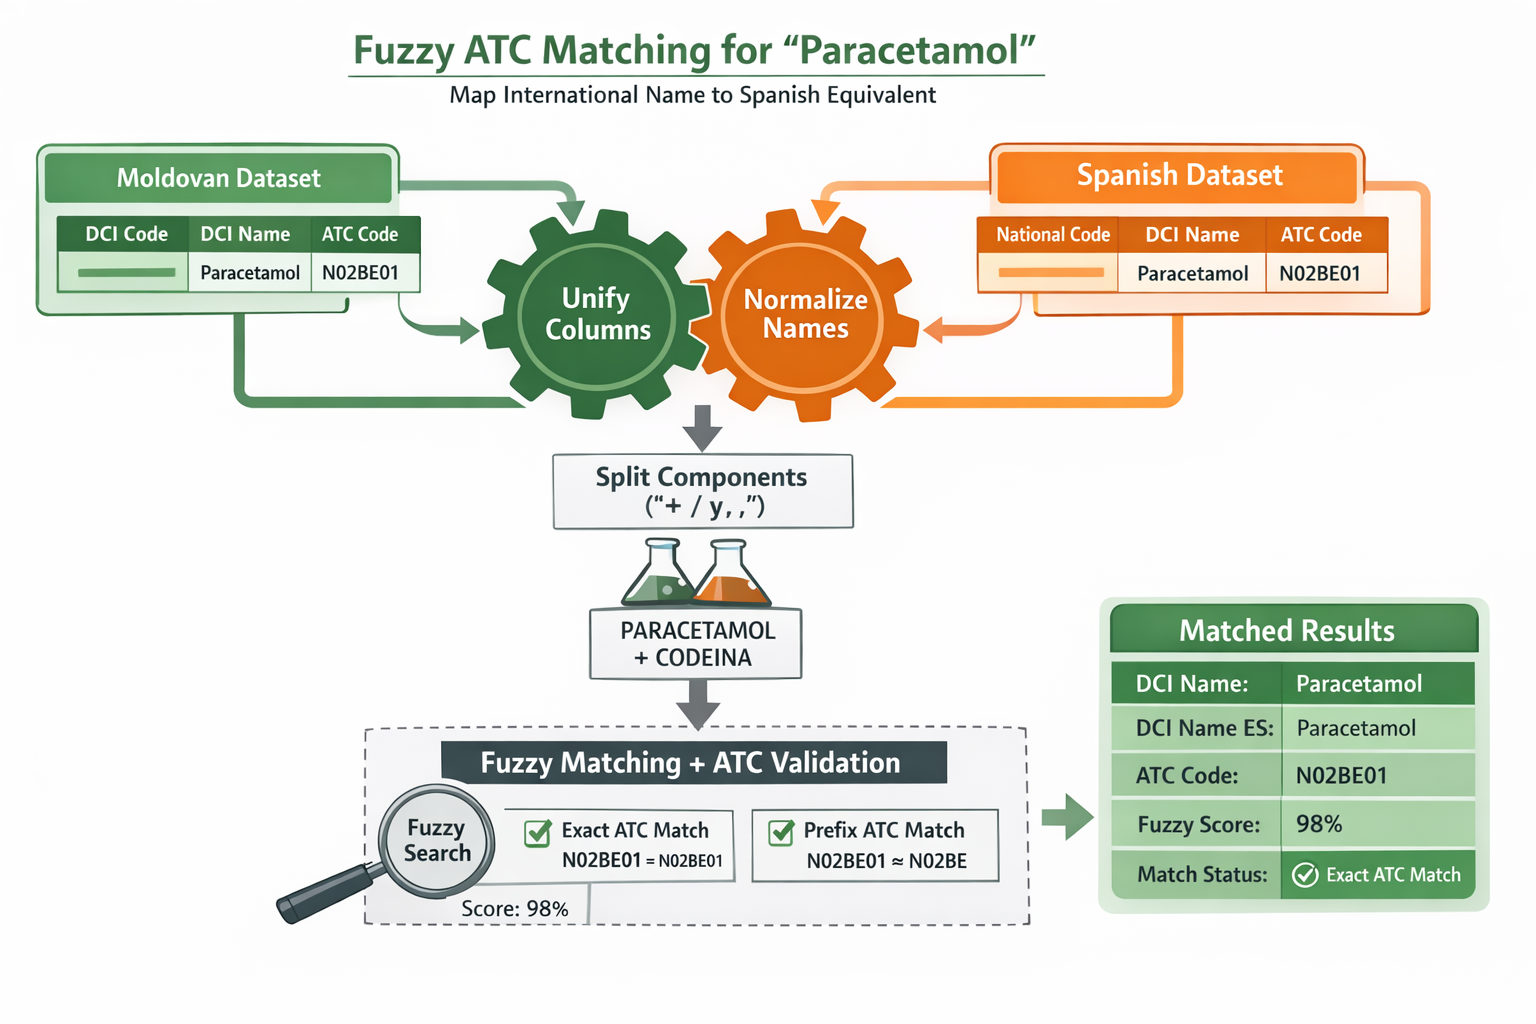
<span style="color:white; font-family: 'Courier New'; font-size: 8"> - generated with ChatGPT </span>


#### <p style="color:green; font-family: 'Courier New'; font-size: 18; text-align: center"> Mapping Rate:</p>

#### **<p style="color:green; font-family: 'Courier New'; font-size: 32px; text-align: center"> > 95% </p>**

In [ ]:
# Statistics on algorythm success
display(matches["match_status"].value_counts().reset_index())

,match_status,count
0,atc_exact_best_score,1396
1,no_candidates,69
2,atc_prefix_best_score,2


In [167]:
import plotly.graph_objects as go

fig = go.Figure()

# Square 1 at (1,1) to (2,2)
fig.add_trace(go.Scatter(
    x=[1, 2, 2, 1, 1],
    y=[1, 1, 2, 2, 1],
    mode='lines',
    fill='toself',
    fillcolor='rgba(149, 219, 229, 1)',
    line=dict(color='rgba(149, 219, 229, 1)'),
    hoverinfo='skip',
    showlegend=False
))

# Square 2 at (3,1) to (4,2)
fig.add_trace(go.Scatter(
    x=[3, 4, 4, 3, 3],
    y=[1, 1, 2, 2, 1],
    mode='lines',
    fill='toself',
    fillcolor='rgba(7, 130, 130, 1.0)',
    line=dict(color='rgba(7, 130, 130, 1.0)'),
    hoverinfo='skip',
    showlegend=False
))

# Square 3 at (5,1) to (6,2)
fig.add_trace(go.Scatter(
    x=[5, 6, 6, 5, 5],
    y=[1, 1, 2, 2, 1],
    mode='lines',
    fill='toself',
    fillcolor='rgba(51, 158, 102, 1)',
    line=dict(color='rgba(51, 158, 102, 1)'),
    hoverinfo='skip',
    showlegend=False
))

# Add text annotations inside each square (centered)
fig.add_annotation(
    x=1.5, y=1.5,  # Center of first square
    text="1396 cases",
    showarrow=False,
    font=dict(color="white", size=20)
)
fig.add_annotation(
    x=1.5, y=0.75,  # Center of first square
    text="atc_exact_best_score",
    showarrow=False,
    font=dict(color="black", size=20)
)

fig.add_annotation(
    x=3.5, y=1.5,  # Center of second square
    text="4,7% fails",
    showarrow=False,
    font=dict(color="white", size=20)
)
fig.add_annotation(
    x=3.5, y=0.75,  # Center of second square
    text="no_candidates",
    showarrow=False,
    font=dict(color="black", size=20)
)

fig.add_annotation(
    x=5.5, y=1.5,  # Center of third square
    text="2 cases",
    showarrow=False,
    font=dict(color="white", size=20)
)
fig.add_annotation(
    x=5.5, y=0.75,  # Center of third square
    text="atc_prefix_best_score",
    showarrow=False,
    font=dict(color="black", size=20)
)

# Set layout to hide axes and grid for a clean look
fig.update_layout(
    xaxis=dict(visible=False, range=[0, 7]),
    yaxis=dict(visible=False, range=[0, 3]),
    paper_bgcolor='white',
    plot_bgcolor='white',
    margin=dict(l=0, r=0, t=0, b=0)
)

fig.show()   

In [280]:
# Saving back-up mapping
matches.to_csv('reporting/fuzzymatching.csv')

In [206]:
drug_cover_md[["atc_code", "dci_name", "dc_name", "is_covered", "manufacturer_name", "manufacturer_label", "country"]].sort_values(by='atc_code').head(2)

,atc_code,dci_name,dc_name,is_covered,manufacturer_name,manufacturer_label,country
502,A02BA03,FAMOTIDINUM,Quamatel® Mini,True,Gedeon Richter SA,Gedeon Richter,Ungaria
1212,A02BA03,FAMOTIDINUM,Famotidin-BP,True,"SC Balkan Pharmaceuticals SRL, Republica Moldo...",Balkan Pharmaceuticals,Republica Moldova


In [210]:
drug_cover_es[["is_covered"]].fillna(False).astype(bool)
drug_cover_es[["atc_code", "dci_name", "dc_name", "is_covered", "manufacturer_name", "manufacturer_label", "country"]].sort_values(by='atc_code').head(2)

,atc_code,dci_name,dc_name,is_covered,manufacturer_name,manufacturer_label,country
48871,A01AB,"RESORCINOL, TETRACAINA HIDROCLORURO, BENZALCON...","RESORBORINA SOLUCION, 1 frasco de 100 ml",False,Laboratorios Ern S.A.,Laboratorios Ern,Spain
11371,A01AB,"RESORCINOL, TETRACAINA HIDROCLORURO, BENZALCON...","RESORBORINA SOLUCION, 1 frasco de 200 ml",False,Laboratorios Ern S.A.,Laboratorios Ern,Spain


In [216]:
drug_cover = pd.concat([
    drug_cover_md[["atc_code", "dci_name", "dc_name", "is_covered", "manufacturer_name", "manufacturer_label", "country"]].sort_values(by='atc_code'),
    drug_cover_es[["atc_code", "dci_name", "dc_name", "is_covered", "manufacturer_name", "manufacturer_label", "country"]].sort_values(by='atc_code'),
    ],
    keys=['md', 'es']
)
drug_cover = drug_cover.reset_index(level=0).rename(columns={'level_0': 'source'})   
drug_cover.tail()

,source,atc_code,dci_name,dc_name,is_covered,manufacturer_name,manufacturer_label,country
1809,es,V10XX,LUTECIO (177) CLORURO,ENDOLUCINBETA 40 GBQ/ML PRECURSOR RADIOFARMACE...,False,Itm Medical Isotopes Gmbh,Itf,Germany
48819,es,V10XX02,IBRITUMOMAB TIUXETAN,"ZEVALIN 1,6 mg/ml, EQUIPO REACTIVO PARA LA PRE...",True,Ceft Biopharma S.R.O.,Ceft Biopharma,Czech Republic
13260,es,V10XX03,RADIO 223 DICLORURO,Xofigo 1100 kBq/ml solucion inyectable 6 ml,False,Bayer Ag,Bayer,Germany
17707,es,V10XX04,LUTECIO (177LU) OXODOTREOTIDA,"LUTATHERA 370 MBQ/ML SOLUCION PARA PERFUSION, ...",False,Advanced Accelerator Applications,Advanced Accelerator Applications,France
42674,es,V10XX05,LUTECIO (177LU) VIPIVOTIDA TETRAXETAN,PLUVICTO 1 000 MBQ/ML SOLUCION INYECTABLE Y PA...,False,Novartis Europharm Limited,Novartis,Ireland


In [281]:
drug_cover.to_csv("reporting/drug_coverage.csv")

In [221]:
dim_atc_codes = pd.DataFrame(drug_cover["atc_code"]).drop_duplicates()
dim_atc_codes.sort_values(by='atc_code', inplace=True)
dim_atc_codes['id'] = range(1, len(dim_atc_codes)+1)
dim_atc_codes = dim_atc_codes[['id', 'atc_code']]
print(dim_atc_codes.info())
dim_atc_codes.head(6)

<class 'pandas.core.frame.DataFrame'>
Index: 2178 entries, 48871 to 42674
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        2178 non-null   int64 
 1   atc_code  2178 non-null   object
dtypes: int64(1), object(1)
memory usage: 51.0+ KB
None


,id,atc_code
48871,1,A01AB
50255,2,A01AB09
12907,3,A01AC03
30154,4,A01AD02
49744,5,A01AD11
26656,6,A02AA04


<hr style="border: none; border-top: 6px solid #FFF111;">

In [225]:
pd.DataFrame(drug_cover[["atc_code", "source"]])["source"].value_counts()

source
es    52735
md     1467
Name: count, dtype: int64

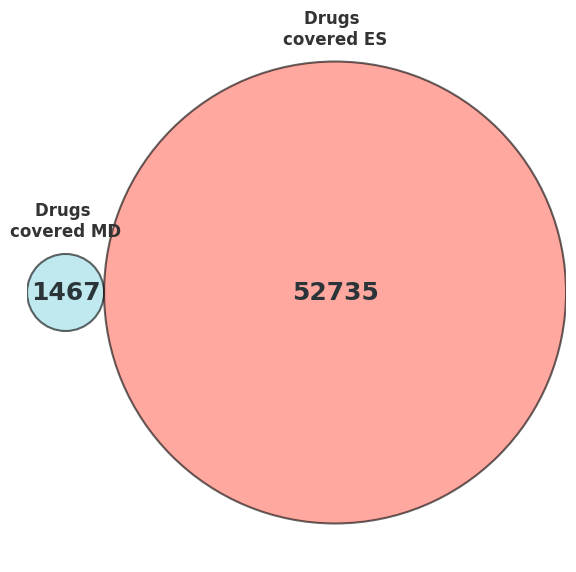

In [279]:
import circlify as circ
import matplotlib.pyplot as plt

data = [
    {'id': 'Drugs \ncovered ES', 'datum': 52735},
    {'id': 'Drugs \ncovered MD', 'datum': 1467}
]

circles = circ.circlify(
    data,
    show_enclosure=False,
    target_enclosure=circ.Circle(0, 0, 1)
)

fig, ax = plt.subplots(figsize=(7, 7))
ax.set_aspect('equal')
ax.axis('off')

# Set limits
lim = max(
    max(abs(circle.x) + circle.r, abs(circle.y) + circle.r)
    for circle in circles
)
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)

# One color per circle
colors = ['#95DBE5FF', '#FF6F61']

for i, circle in enumerate(circles):
    if 'id' not in circle.ex:
        continue

    x, y, r = circle.x, circle.y, circle.r
    label = circle.ex['id']
    value = circle.ex['datum']

    # Draw circle
    ax.add_patch(
        plt.Circle(
            (x, y),
            r,
            alpha=0.6,
            edgecolor='black',
            facecolor=colors[i % len(colors)],
            linewidth=1.5
        )
    )

    # Value in the center
    ax.text(
        x, y,
        f"{value}",
        ha='center',
        va='center',
        fontsize=18,
        fontweight='bold',
        color='#2A3439'
    )

    # Label above the circle
    ax.text(
        x, y + r + 0.05,
        label,
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold',
        color='#333333'
    )

plt.show()